# Week7 CNN 与 Multi-sight 实验

1. 将 $(B, T)$ 的序列变换为 $(B, 1, H, W)$；
2. 搭建包含 `Conv2d` 的 CNN 回归模型；
3. 比较不同卷积核大小 `3 / 5 / 7`；
4. 构建 `Multi-sight` 多分支 CNN；


In [1]:
import os
import sys
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week7' else _cwd
sys.path.insert(0, os.path.join(_root, 'week5'))
sys.path.insert(0, os.path.join(_root, 'week7'))

from data import Electricity
from models import CNNRegressor, MultiSightCNN
from transforms import make_2d_forecasting_data

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'Device: {device}')

Torch version: 2.6.0+cu124
Device: cuda


## 1. 实验参数

这里把一段长度为 `168` 的历史序列重排成 `24 x 7` 的二维矩阵：

- `24` 表示一天内 24 个小时；
- `7` 表示连续 7 天

In [2]:
SEQ_LEN = 168
PRED_LEN = 1
HEIGHT = 24
WIDTH = 7
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
RANDOM_SEED = 42
MAX_USERS = 20
MAX_SAMPLES = 1000

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

assert HEIGHT * WIDTH == SEQ_LEN

## 2. 读取 electricity 数据并构造滑窗样本

这里直接复用第五周的 `Electricity` 数据加载器。

In [3]:
elec = Electricity(test_ratio=0.2, max_users=MAX_USERS, max_samples_per_user=MAX_SAMPLES)
X_train, y_train, X_test, y_test = elec.get_global_slided_dataset(
    d_num=SEQ_LEN,
    h_num=PRED_LEN,
    use_global_scaler=True,
)

print(f'用户数: {elec.n_users}')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

if X_train.ndim != 2 or X_test.ndim != 2 or len(X_test) == 0:
    raise ValueError(
        '当前参数下没有构造出有效的训练/测试滑窗。'
        '请增大 MAX_SAMPLES，或减小 SEQ_LEN。'
    )

用户数: 20
X_train shape: (12640, 168)
y_train shape: (12640, 1)
X_test shape: (640, 168)
y_test shape: (640, 1)


## 3. 检查点一：1D-to-2D 变换


In [4]:
X_train_2d, y_train_2d, X_test_2d, y_test_2d = make_2d_forecasting_data(
    X_train,
    y_train,
    X_test,
    y_test,
    height=HEIGHT,
    width=WIDTH,
)

print(f'原始序列形状: {X_train.shape} = [Batch, T]')
print(f'变换后形状: {X_train_2d.shape} = [Batch, 1, H, W]')
print(f'单个样本 2D 矩阵形状: {X_train_2d[0, 0].shape} = [H, W]')

原始序列形状: (12640, 168) = [Batch, T]
变换后形状: (12640, 1, 24, 7) = [Batch, 1, H, W]
单个样本 2D 矩阵形状: (24, 7) = [H, W]


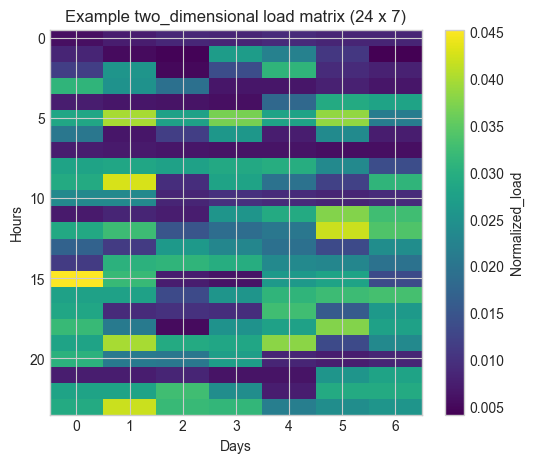

In [5]:
# 可视化一个样本的二维矩阵，帮助理解 1D 转 2D 后的结构。
sample_matrix = X_train_2d[0, 0]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sample_matrix, aspect='auto', cmap='viridis')
ax.set_title('Example two_dimensional load matrix (24 x 7)')
ax.set_xlabel('Days')
ax.set_ylabel('Hours')
plt.colorbar(im, ax=ax, label='Normalized_load')
plt.show()

## 4. 构建 DataLoader

从这里开始，所有 CNN 输入统一采用 `[Batch, 1, H, W]`。

In [6]:
train_ds = TensorDataset(torch.from_numpy(X_train_2d), torch.from_numpy(y_train_2d))
test_ds = TensorDataset(torch.from_numpy(X_test_2d), torch.from_numpy(y_test_2d))

print(f'train samples: {len(train_ds)}')
print(f'test samples: {len(test_ds)}')

if len(train_ds) == 0 or len(test_ds) == 0:
    raise ValueError(
        'DataLoader 为空，当前参数下没有构造出足够样本。'
        '请确认已重新运行参数单元，并保证 MAX_SAMPLES 足够大。'
    )

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

train samples: 12640
test samples: 640


## 5. 训练与评估函数

为了方便比较不同卷积核大小和 `Multi-sight` 模型，这里先封装训练循环。

In [7]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    if len(data_loader.dataset) == 0:
        raise ValueError('evaluate_model 收到空数据集，请先检查测试样本是否为 0。')

    with torch.no_grad(): # 关闭梯度，无需反向传播更新权重
        for x_b, y_b in data_loader:
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            y_hat = model(x_b)
            loss = criterion(y_hat, y_b)
            total_loss += loss.item() * x_b.size(0) # loss.item() 为当前batch的loss平均值，x_b.size(0) 为当前batch的样本数
            preds.append(y_hat.cpu().numpy())
            targets.append(y_b.cpu().numpy())

    if not preds or not targets:
        raise ValueError('evaluate_model 未收到任何 batch，请检查 test_loader。')

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    mse = np.mean((preds - targets) ** 2)
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(mse)
    avg_loss = total_loss / len(data_loader.dataset)
    return avg_loss, mae, rmse


def train_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_mae': [],
        'test_rmse': [],
    }
    best_state = deepcopy(model.state_dict())
    best_rmse = float('inf')

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x_b, y_b in train_loader:
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            optimizer.zero_grad()
            y_hat = model(x_b)
            loss = criterion(y_hat, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x_b.size(0)

        train_loss = total_loss / len(train_loader.dataset)
        test_loss, test_mae, test_rmse = evaluate_model(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_mae'].append(test_mae)
        history['test_rmse'].append(test_rmse)

        if test_rmse < best_rmse:
            best_rmse = test_rmse
            best_state = deepcopy(model.state_dict())

        print(
            f'Epoch {epoch + 1:02d}/{epochs} | '
            f'train_loss={train_loss:.5f} | '
            f'test_loss={test_loss:.5f} | '
            f'test_mae={test_mae:.5f} | '
            f'test_rmse={test_rmse:.5f}'
        )

    model.load_state_dict(best_state)
    return model, history

## 6. 单尺度 CNN：比较不同卷积核 `3 / 5 / 7`


In [8]:
single_scale_results = {}

for kernel_size in (3, 5, 7):
    print(f'\n===== Training single-scale CNN, kernel_size={kernel_size} =====')
    model = CNNRegressor(
        in_channels=1,
        hidden_channels=16,
        kernel_size=kernel_size,
        output_dim=PRED_LEN,
    ).to(device)

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=EPOCHS,
        lr=LR,
        device=device,
    )
    single_scale_results[kernel_size] = {
        'model': model,
        'history': history,
        'best_rmse': min(history['test_rmse']),
        'best_mae': min(history['test_mae']),
    }


===== Training single-scale CNN, kernel_size=3 =====
Epoch 01/10 | train_loss=0.00891 | test_loss=0.00469 | test_mae=0.04143 | test_rmse=0.06851
Epoch 02/10 | train_loss=0.00513 | test_loss=0.00512 | test_mae=0.04137 | test_rmse=0.07155
Epoch 03/10 | train_loss=0.00493 | test_loss=0.00441 | test_mae=0.03938 | test_rmse=0.06644
Epoch 04/10 | train_loss=0.00472 | test_loss=0.00425 | test_mae=0.03935 | test_rmse=0.06516
Epoch 05/10 | train_loss=0.00444 | test_loss=0.00388 | test_mae=0.03782 | test_rmse=0.06232
Epoch 06/10 | train_loss=0.00404 | test_loss=0.00370 | test_mae=0.04068 | test_rmse=0.06083
Epoch 07/10 | train_loss=0.00352 | test_loss=0.00311 | test_mae=0.03390 | test_rmse=0.05577
Epoch 08/10 | train_loss=0.00295 | test_loss=0.00228 | test_mae=0.03055 | test_rmse=0.04773
Epoch 09/10 | train_loss=0.00244 | test_loss=0.00191 | test_mae=0.02773 | test_rmse=0.04371
Epoch 10/10 | train_loss=0.00209 | test_loss=0.00150 | test_mae=0.02491 | test_rmse=0.03869

===== Training single-sca

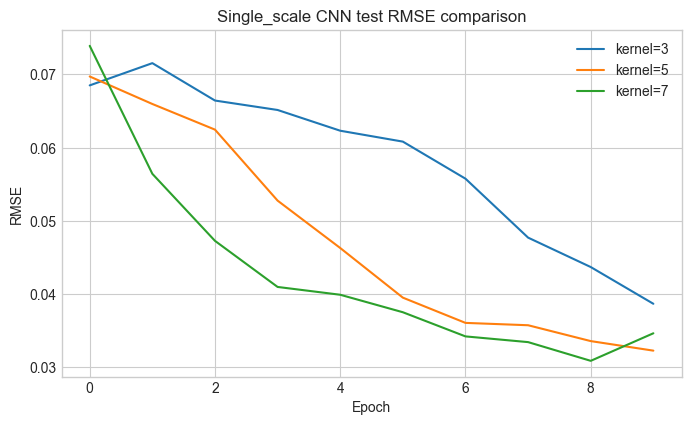

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for kernel_size, result in single_scale_results.items():
    ax.plot(result['history']['test_rmse'], label=f'kernel={kernel_size}')
ax.set_title('Single_scale CNN test RMSE comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.legend()
plt.show()

## 7. Multi-sight CNN：融合 `3 / 5 / 7` 三个尺度

这里用三个不同卷积核的分支同时提取特征，再拼接后输出预测值。

In [10]:
print('\n===== Training Multi-sight CNN =====')
multi_sight_model = MultiSightCNN(
    in_channels=1,
    hidden_channels=16,
    kernel_sizes=(3, 5, 7),
    output_dim=PRED_LEN,
    dropout=0.1,
).to(device)

multi_sight_model, multi_sight_history = train_model(
    model=multi_sight_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)


===== Training Multi-sight CNN =====
Epoch 01/10 | train_loss=0.00712 | test_loss=0.00466 | test_mae=0.03999 | test_rmse=0.06827
Epoch 02/10 | train_loss=0.00531 | test_loss=0.00427 | test_mae=0.04067 | test_rmse=0.06538
Epoch 03/10 | train_loss=0.00428 | test_loss=0.00273 | test_mae=0.03329 | test_rmse=0.05226
Epoch 04/10 | train_loss=0.00238 | test_loss=0.00167 | test_mae=0.02579 | test_rmse=0.04089
Epoch 05/10 | train_loss=0.00165 | test_loss=0.00126 | test_mae=0.02287 | test_rmse=0.03551
Epoch 06/10 | train_loss=0.00149 | test_loss=0.00103 | test_mae=0.02018 | test_rmse=0.03202
Epoch 07/10 | train_loss=0.00131 | test_loss=0.00095 | test_mae=0.01935 | test_rmse=0.03082
Epoch 08/10 | train_loss=0.00127 | test_loss=0.00115 | test_mae=0.02177 | test_rmse=0.03398
Epoch 09/10 | train_loss=0.00120 | test_loss=0.00086 | test_mae=0.01881 | test_rmse=0.02939
Epoch 10/10 | train_loss=0.00109 | test_loss=0.00092 | test_mae=0.01954 | test_rmse=0.03036


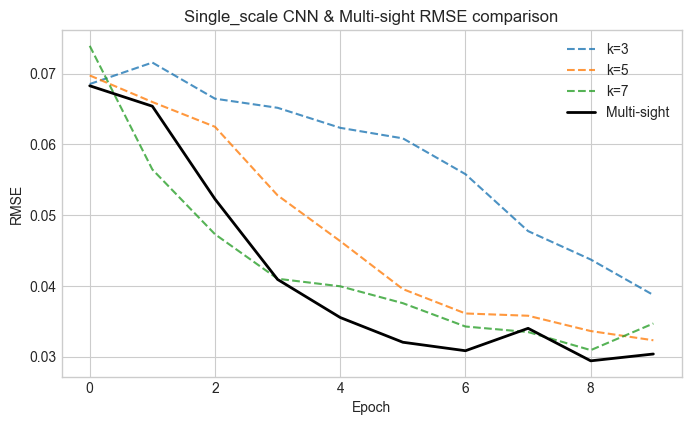

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for kernel_size, result in single_scale_results.items():
    ax.plot(result['history']['test_rmse'], linestyle='--', alpha=0.8, label=f'k={kernel_size}')
ax.plot(multi_sight_history['test_rmse'], color='black', linewidth=2, label='Multi-sight')
ax.set_title('Single_scale CNN & Multi-sight RMSE comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.legend()
plt.show()

## 8. 结果汇总表


In [12]:
summary_rows = []

for kernel_size, result in single_scale_results.items():
    summary_rows.append({
        'model': f'CNN-k{kernel_size}',
        'best_test_mae': min(result['history']['test_mae']),
        'best_test_rmse': min(result['history']['test_rmse']),
    })

summary_rows.append({
    'model': 'Multi-sight(3,5,7)',
    'best_test_mae': min(multi_sight_history['test_mae']),
    'best_test_rmse': min(multi_sight_history['test_rmse']),
})

summary_df = pd.DataFrame(summary_rows).sort_values(by='best_test_rmse').reset_index(drop=True)
summary_df

,model,best_test_mae,best_test_rmse
0,"Multi-sight(3,5,7)",0.018811,0.029390
1,CNN-k7,0.018467,0.030904
2,CNN-k5,0.018651,0.032295
3,CNN-k3,0.024913,0.038694


## 9. `Multi-sight` 的物理意义

`Multi-sight` 的物理意义，可以理解为“用不同大小的观察窗口同时看负荷矩阵”，从而同时捕捉不同频率的模式：

- `kernel = 3`：更关注高频、短时局部波动；
- `kernel = 5`：兼顾局部波动与更平滑的半天尺度变化；
- `kernel = 7`：更偏向低频、跨天的平滑结构。

当输入被 reshape 成 `24 x 7` 之后，卷积核既可以沿着“小时方向”提取日内规律，也可以沿着“天方向”提取跨天重复模式。因此，`Multi-sight` 本质上是在并行学习高频与低频特征。